In [1]:
import pickle
%load_ext autoreload
%autoreload 2

In [2]:
import contextlib
import copy
import io
import os
import queue
import threading
from datetime import date
from itertools import product
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
from sklearn.metrics import root_mean_squared_error, r2_score

from aquacrop import AquaCrop, Crop, Soil, Weather
from aquacrop_slovenia import config
from aquacrop_slovenia.diagnostics import nse, kge, mkge, kge_r, kge_beta, kge_alpha, mkge_alpha
from aquacrop_slovenia.plots import plot_yield_timeseries_comparison, plot_yield_scatter, plot_yield_timeseries_residuals
from aquacrop_slovenia.reading_data import get_yield, get_yield_for_comparison, get_co2_for_aquacrop, get_station_weather
from aquacrop_slovenia.parameter_defaults_jablje import (
    jablje_soil_layers,
    jablje_curve_number,
    jablje_readily_evaporable_water,
    jablje_maize_params,
    jablje_optimal_management,
    jablje_initial_cond,
    jablje_groundwater,
)

Loaded data sizes: Temperatures=1096, ETo=1096, Rain=1096


In [3]:
LOCATION = "jablje"
MAX_WORKERS = os.cpu_count()

simulation_periods = [
    {
        "start_date": date(year, 1, 1),
        "end_date": date(year, 12, 31),
        "planting_date": date(year, 5, 3),
        "is_seeding_year": True,
    }
    for year in range(1993, 2024)
    if year not in [2017]
]

temperatures, eto, rain = get_station_weather(8)
historical_co2 = get_co2_for_aquacrop("historical")

weather = Weather(
    location=LOCATION,
    temperatures=temperatures,
    eto_values=eto,
    rainfall_values=rain,
    record_type=1,
    first_day=1,
    first_month=1,
    first_year=1993,
    co2_records=historical_co2,
)

soil = Soil(
    name=f"{LOCATION} soil",
    description=f"{LOCATION} loamy sand soil",
    soil_layers=jablje_soil_layers,
    curve_number=jablje_curve_number,
    readily_evaporable_water=jablje_readily_evaporable_water,
)

observed_biomass = get_yield_for_comparison(LOCATION, "biomass", "A", "N3")
observed_grain = get_yield_for_comparison(LOCATION, "grain", "A", "N3")

INTEGER_PARAMS = {name for name, val in jablje_maize_params.items() if isinstance(val, int)}

In [4]:
# Parameters to search and their grid values (bounds from Optimization Jablje)
grid_params = {
    "harvest_index":        np.linspace(0.46, 0.56, 6),
    "gdd_senescence":       np.linspace(1000, 1150, 5),
    "gdd_maturity":         np.linspace(1200, 1400, 5),
    "gdd_flowering":        np.linspace(480, 530, 5),
    "gdd_flowering_length": np.linspace(130, 170, 3),
    "max_canopy_cover":     np.linspace(0.85, 0.95, 5),
    #"min_rooting_depth":    np.linspace(0.2, 0.4, 3),
    #"max_rooting_depth":    np.linspace(1.8, 2.5, 3),
}

param_names = list(grid_params.keys())
grid_combinations = list(product(*grid_params.values()))

grid_shape = " x ".join(str(len(v)) for v in grid_params.values())
print(f"Grid: {grid_shape} = {len(grid_combinations):,} combinations")
print(f"Workers: {MAX_WORKERS}")

Grid: 6 x 5 x 5 x 5 x 3 x 5 = 11,250 combinations
Workers: 28


In [5]:
# Pre-create one working directory per worker to avoid conflicts
worker_dirs = []
for i in range(MAX_WORKERS):
    d = config.RAMDISK_DIR / f"grid_jablje_{i}"
    d.mkdir(parents=True, exist_ok=True)
    worker_dirs.append(d)

dir_queue = queue.Queue()
for d in worker_dirs:
    dir_queue.put(d)

print(f"Worker directories: {[str(d) for d in worker_dirs]}")

Worker directories: ['E:aquacrop\\grid_jablje_0', 'E:aquacrop\\grid_jablje_1', 'E:aquacrop\\grid_jablje_2', 'E:aquacrop\\grid_jablje_3', 'E:aquacrop\\grid_jablje_4', 'E:aquacrop\\grid_jablje_5', 'E:aquacrop\\grid_jablje_6', 'E:aquacrop\\grid_jablje_7', 'E:aquacrop\\grid_jablje_8', 'E:aquacrop\\grid_jablje_9', 'E:aquacrop\\grid_jablje_10', 'E:aquacrop\\grid_jablje_11', 'E:aquacrop\\grid_jablje_12', 'E:aquacrop\\grid_jablje_13', 'E:aquacrop\\grid_jablje_14', 'E:aquacrop\\grid_jablje_15', 'E:aquacrop\\grid_jablje_16', 'E:aquacrop\\grid_jablje_17', 'E:aquacrop\\grid_jablje_18', 'E:aquacrop\\grid_jablje_19', 'E:aquacrop\\grid_jablje_20', 'E:aquacrop\\grid_jablje_21', 'E:aquacrop\\grid_jablje_22', 'E:aquacrop\\grid_jablje_23', 'E:aquacrop\\grid_jablje_24', 'E:aquacrop\\grid_jablje_25', 'E:aquacrop\\grid_jablje_26', 'E:aquacrop\\grid_jablje_27']


In [6]:
def evaluate_params(param_values):
    """Run one grid point and return parameter values + all scores for both grain and biomass."""
    working_dir = dir_queue.get()
    try:
        params = copy.deepcopy(jablje_maize_params)
        for name, val in zip(param_names, param_values):
            params[name] = int(round(val)) if name in INTEGER_PARAMS else float(val)

        crop = Crop(
            name=f"{LOCATION} maize",
            description="grid search",
            params=params,
        )

        simulation = AquaCrop(
            simulation_periods=simulation_periods,
            crop=crop,
            soil=soil,
            management=jablje_optimal_management,
            initial_conditions=jablje_initial_cond,
            climate=weather,
            #ground_water=jablje_groundwater,
            working_dir=working_dir,
            need_daily_output=False,
            need_seasonal_output=True,
            need_harvest_output=False,
            need_evaluation_output=False,
        )

        nan_metrics = {f"{prefix}_{s}": np.nan
                       for prefix in ("biomass", "grain")
                       for s in ["rmse", "r2", "nse", "kge", "mkge", "kge_r", "kge_beta", "kge_alpha", "mkge_alpha"]}

        try:
            with contextlib.redirect_stdout(io.StringIO()):
                results = simulation.run()
        except Exception:
            return {**dict(zip(param_names, param_values)), **nan_metrics}

        seasonal = results["season"][["Year1", "BioMass", "Y(dry)"]].rename(
            columns={"Year1": "year", "BioMass": "biomass_modeled", "Y(dry)": "grain_modeled"}
        )

        def compute_metrics(observed_df, modeled_col, prefix):
            merged = observed_df.merge(seasonal[["year", modeled_col]], on="year")
            y_obs = merged["yield"].values
            y_mod = merged[modeled_col].values
            return {
                f"{prefix}_rmse":       root_mean_squared_error(y_obs, y_mod),
                f"{prefix}_r2":         r2_score(y_obs, y_mod),
                f"{prefix}_nse":        nse(y_mod, y_obs),
                f"{prefix}_kge":        kge(y_mod, y_obs),
                f"{prefix}_mkge":       mkge(y_mod, y_obs),
                f"{prefix}_kge_r":      kge_r(y_mod, y_obs),
                f"{prefix}_kge_beta":   kge_beta(y_mod, y_obs),
                f"{prefix}_kge_alpha":  kge_alpha(y_mod, y_obs),
                f"{prefix}_mkge_alpha": mkge_alpha(y_mod, y_obs),
            }

        return {
            **dict(zip(param_names, param_values)),
            **compute_metrics(observed_biomass, "biomass_modeled", "biomass"),
            **compute_metrics(observed_grain, "grain_modeled", "grain"),
        }
    finally:
        dir_queue.put(working_dir)

360 simulacij / 1 minuto

In [19]:
total = len(grid_combinations)
results_list = []

print(f"Running {total:,} simulations with {MAX_WORKERS} workers...")
print(f"Approximate running time: {total // 360} min")

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = [executor.submit(evaluate_params, combo) for combo in grid_combinations]
    for future in as_completed(futures):
        results_list.append(future.result())

results_df = pd.DataFrame(results_list).sort_values("grain_rmse").reset_index(drop=True)
print(f"\nComplete. Failed runs: {results_df['biomass_rmse'].isna().sum()}")


KeyboardInterrupt



In [13]:
output_path = config.RESULTS_DIR / "grid_search_jablje_7_biomass.pkl"
results_df.to_pickle(output_path)
print(f"Saved {len(results_df):,} rows to {output_path}")

In [8]:
output_path = config.RESULTS_DIR / "grid_search_jablje_7_biomass.pkl"
results_df = pd.read_pickle(output_path)

In [9]:
results_df

,harvest_index,gdd_senescence,gdd_maturity,gdd_flowering,gdd_flowering_length,max_canopy_cover,biomass_rmse,biomass_r2,biomass_nse,biomass_kge,...,biomass_mkge_alpha,grain_rmse,grain_r2,grain_nse,grain_kge,grain_mkge,grain_kge_r,grain_kge_beta,grain_kge_alpha,grain_mkge_alpha
0,0.46,1000.0,1200.0,480.0,130.0,0.85,4.429520,-0.040710,-0.040710,-0.221413,...,0.162879,2.692574,-0.721846,-0.721846,-0.107791,-0.069861,0.218810,0.808835,0.238161,0.294449
1,0.56,1000.0,1200.0,480.0,130.0,0.85,4.429520,-0.040710,-0.040710,-0.221413,...,0.162879,2.012799,0.037813,0.037813,-0.055857,-0.052825,0.218719,0.984659,0.289930,0.294447
2,0.50,1000.0,1200.0,480.0,130.0,0.85,4.429520,-0.040710,-0.040710,-0.221413,...,0.162879,2.304345,-0.261112,-0.261112,-0.083596,-0.059580,0.218782,0.879169,0.258866,0.294444
3,0.54,1000.0,1200.0,480.0,130.0,0.85,4.429520,-0.040710,-0.040710,-0.221413,...,0.162879,2.061672,-0.009481,-0.009481,-0.063860,-0.053849,0.218837,0.949503,0.279560,0.294428
4,0.48,1000.0,1200.0,480.0,130.0,0.85,4.429520,-0.040710,-0.040710,-0.221413,...,0.162879,2.483901,-0.465303,-0.465303,-0.095191,-0.064202,0.218764,0.844009,0.248481,0.294405
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11245,0.50,1150.0,1400.0,530.0,170.0,0.95,8.239957,-2.601358,-2.601358,-0.202487,...,0.149796,2.655473,-0.674721,-0.674721,-0.083202,-0.116420,0.109721,1.168638,0.406458,0.347805
11246,0.46,1150.0,1400.0,530.0,170.0,0.95,8.239957,-2.601358,-2.601358,-0.202487,...,0.149796,2.225831,-0.176639,-0.176639,-0.090959,-0.106165,0.109747,1.075153,0.373907,0.347771
11247,0.52,1150.0,1400.0,530.0,170.0,0.95,8.239957,-2.601358,-2.601358,-0.202487,...,0.149796,2.946887,-1.062461,-1.062461,-0.082638,-0.124369,0.109789,1.215378,0.422730,0.347817
11248,0.56,1150.0,1400.0,530.0,170.0,0.95,8.239957,-2.601358,-2.601358,-0.202487,...,0.149796,3.622102,-2.115876,-2.115876,-0.088509,-0.146054,0.109668,1.308874,0.455245,0.347814


In [11]:
results_df.sort_values("grain_kge_r").reset_index(drop=True)

,harvest_index,gdd_senescence,gdd_maturity,gdd_flowering,gdd_flowering_length,max_canopy_cover,biomass_rmse,biomass_r2,biomass_nse,biomass_kge,...,biomass_mkge_alpha,grain_rmse,grain_r2,grain_nse,grain_kge,grain_mkge,grain_kge_r,grain_kge_beta,grain_kge_alpha,grain_mkge_alpha
0,0.46,1150.0,1200.0,505.0,150.0,0.900,5.244691,-0.459003,-0.459003,-0.229104,...,0.160110,2.313247,-0.270875,-0.270875,-0.232403,-0.215144,0.014293,0.900783,0.266955,0.296358
1,0.48,1150.0,1200.0,505.0,150.0,0.925,5.377148,-0.533630,-0.533630,-0.229487,...,0.160152,2.174998,-0.123509,-0.123509,-0.220748,-0.212105,0.014433,0.950087,0.281396,0.296179
2,0.56,1150.0,1200.0,505.0,150.0,0.925,5.377148,-0.533630,-0.533630,-0.229487,...,0.160152,2.380473,-0.345814,-0.345814,-0.197597,-0.215901,0.014467,1.108436,0.328281,0.296166
3,0.54,1150.0,1200.0,505.0,150.0,0.900,5.244691,-0.459003,-0.459003,-0.229104,...,0.160110,2.208679,-0.158575,-0.158575,-0.202466,-0.212267,0.014518,1.057443,0.313378,0.296355
4,0.48,1150.0,1200.0,505.0,150.0,0.900,5.244691,-0.459003,-0.459003,-0.229104,...,0.160110,2.196091,-0.145406,-0.145406,-0.222765,-0.212351,0.014552,0.939954,0.278584,0.296380
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11245,0.50,1075.0,1350.0,480.0,130.0,0.875,5.434855,-0.566724,-0.566724,-0.180969,...,0.148547,2.004283,0.045937,0.045937,-0.034047,-0.031974,0.231915,0.990023,0.307757,0.310858
11246,0.52,1075.0,1350.0,480.0,130.0,0.875,5.434855,-0.566724,-0.566724,-0.180969,...,0.148547,2.023510,0.027545,0.027545,-0.026204,-0.032331,0.231943,1.029633,0.320069,0.310857
11247,0.48,1075.0,1350.0,480.0,130.0,0.875,5.434855,-0.566724,-0.566724,-0.180969,...,0.148547,2.054016,-0.001997,-0.001997,-0.043398,-0.033051,0.231960,0.950413,0.295490,0.310907
11248,0.56,1075.0,1350.0,480.0,130.0,0.875,5.434855,-0.566724,-0.566724,-0.180969,...,0.148547,2.255502,-0.208218,-0.208218,-0.015451,-0.037605,0.231975,1.108826,0.344686,0.310857


In [12]:
score_cols = ["rmse", "r2", "nse", "kge", "mkge"]
ascending = {"rmse": True, "r2": False, "nse": False, "kge": False, "mkge": False}

for target in ("biomass", "grain"):
    print(f"\n=== {target.upper()} ===")
    for metric in score_cols:
        col = f"{target}_{metric}"
        best = results_df.sort_values(col, ascending=ascending[metric]).iloc[0]
        param_str = ", ".join(f"{p}={best[p]:.4f}" for p in param_names)
        print(f"Best {metric.upper():5s}: {best[col]:.4f}")
        print(f"  {param_str}")


=== BIOMASS ===
Best RMSE : 4.4295
  harvest_index=0.4600, gdd_senescence=1000.0000, gdd_maturity=1200.0000, gdd_flowering=480.0000, gdd_flowering_length=130.0000, max_canopy_cover=0.8500
Best R2   : -0.0407
  harvest_index=0.4600, gdd_senescence=1000.0000, gdd_maturity=1200.0000, gdd_flowering=480.0000, gdd_flowering_length=130.0000, max_canopy_cover=0.8500
Best NSE  : -0.0407
  harvest_index=0.4600, gdd_senescence=1000.0000, gdd_maturity=1200.0000, gdd_flowering=480.0000, gdd_flowering_length=130.0000, max_canopy_cover=0.8500
Best KGE  : -0.1708
  harvest_index=0.5400, gdd_senescence=1150.0000, gdd_maturity=1350.0000, gdd_flowering=480.0000, gdd_flowering_length=130.0000, max_canopy_cover=0.8750
Best MKGE : -0.1950
  harvest_index=0.4600, gdd_senescence=1150.0000, gdd_maturity=1350.0000, gdd_flowering=480.0000, gdd_flowering_length=130.0000, max_canopy_cover=0.8500

=== GRAIN ===
Best RMSE : 2.0026
  harvest_index=0.5200, gdd_senescence=1037.5000, gdd_maturity=1350.0000, gdd_floweri

In [13]:
best = {}

In [23]:
# Re-run with the best parameter set (lowest RMSE) to get full seasonal results for plotting
results_df.sort_values("grain_nse").reset_index(drop=True)
best = results_df.iloc[-1]

best_params = copy.deepcopy(jablje_maize_params)
for name in param_names:
    val = best[name]
    best_params[name] = int(round(val)) if name in INTEGER_PARAMS else float(val)

best_crop = Crop(
    name=f"{LOCATION} maize (best grid)",
    description="best grid search parameters",
    params=best_params,
)

best_dir = config.RAMDISK_DIR / "grid_jablje_best"
best_dir.mkdir(parents=True, exist_ok=True)

best_simulation = AquaCrop(
    simulation_periods=simulation_periods,
    crop=best_crop,
    soil=soil,
    management=jablje_optimal_management,
    initial_conditions=jablje_initial_cond,
    climate=weather,
    #ground_water=jablje_groundwater,
    working_dir=best_dir,
    need_daily_output=False,
    need_seasonal_output=True,
    need_harvest_output=False,
    need_evaluation_output=False,
)

best_results = best_simulation.run()
best_seasonal = best_results["season"]

print(f"RMSE:  {best['grain_rmse']:.4f}")
print(f"R2:    {best['grain_r2']:.4f}")
print(f"NSE:   {best['grain_nse']:.4f}")
print(f"KGE:   {best['grain_kge']:.4f}")
print(f"mKGE:  {best['grain_mkge']:.4f}")

Setting up working directory at: E:\aquacrop\grid_jablje_best
Running AquaCrop simulation with project file: E:\aquacrop\grid_jablje_best\LIST\PROJECT.PRM
Detected platform: windows (AMD64)
Looking for executable at: C:\Users\rokku\Documents\Code\aquacrop-slovenia\.venv\Lib\site-packages\model\windows\aquacrop.exe
Using AquaCrop executable: E:\aquacrop\grid_jablje_best\aquacrop.exe
AquaCrop simulation completed successfully
Parsing simulation results...
Results successfully parsed
RMSE:  3.2722
R2:    -1.5429
NSE:   -1.5429
KGE:   -0.0845
mKGE:  -0.1343


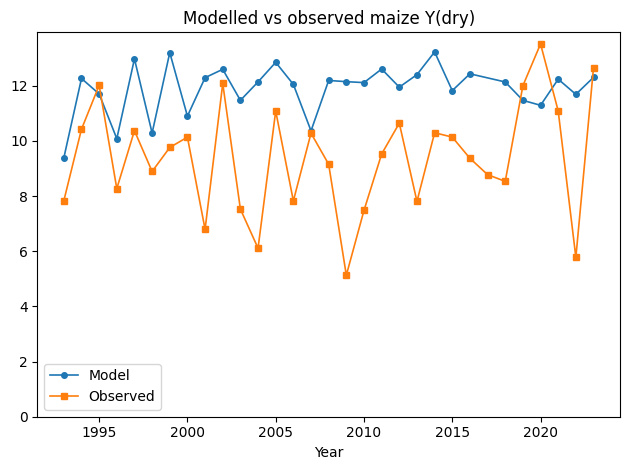

In [24]:
plot_yield_timeseries_comparison(best_seasonal, get_yield(LOCATION, "grain", "A", "N3"), "Y(dry)")

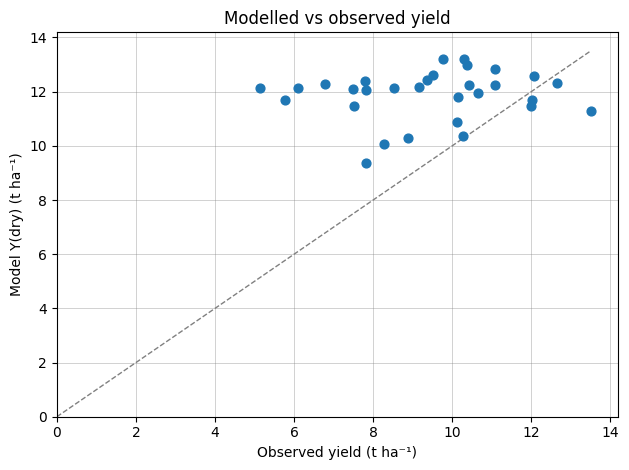

In [25]:
plot_yield_scatter(best_seasonal, get_yield(LOCATION, "grain", "A", "N3"))

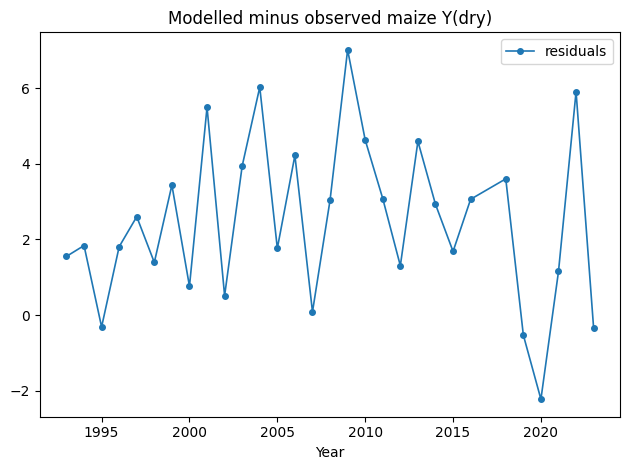

In [26]:
plot_yield_timeseries_residuals(best_seasonal, get_yield_for_comparison(LOCATION, "grain", "A", "N3"), "Y(dry)")

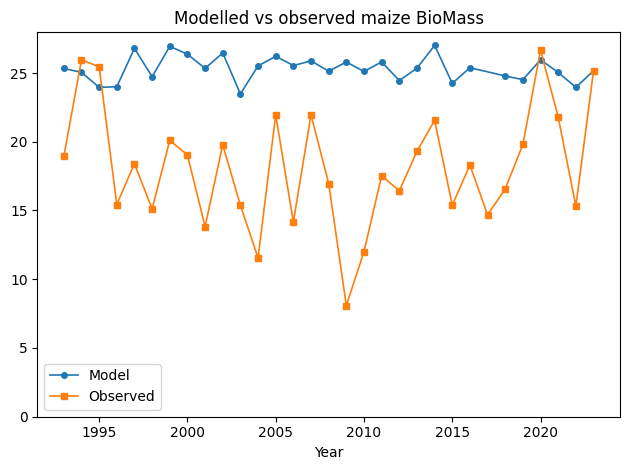

In [27]:
plot_yield_timeseries_comparison(best_seasonal, get_yield(LOCATION, "biomass", "A", "N3"), "BioMass")